# Assignment for Decision Tree

## EDA

In [13]:
from matplotlib.pyplot import grid
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, f1_score, classification_report

import numpy as np
import  pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [18]:
X,y  = load_breast_cancer(return_X_y=True,as_frame=True)
print(X.shape)
print(y.shape)
print(X.columns)

(569, 30)
(569,)
Index(['mean radius', 'mean texture', 'mean perimeter', 'mean area',
       'mean smoothness', 'mean compactness', 'mean concavity',
       'mean concave points', 'mean symmetry', 'mean fractal dimension',
       'radius error', 'texture error', 'perimeter error', 'area error',
       'smoothness error', 'compactness error', 'concavity error',
       'concave points error', 'symmetry error', 'fractal dimension error',
       'worst radius', 'worst texture', 'worst perimeter', 'worst area',
       'worst smoothness', 'worst compactness', 'worst concavity',
       'worst concave points', 'worst symmetry', 'worst fractal dimension'],
      dtype='object')


In [15]:
np.isnan(X).sum()

0

In [32]:
## take corr first
X['target'] = y
X
print(X.corr())

                         mean radius  mean texture  mean perimeter  mean area  \
mean radius                 1.000000      0.323782        0.997855   0.987357   
mean texture                0.323782      1.000000        0.329533   0.321086   
mean perimeter              0.997855      0.329533        1.000000   0.986507   
mean area                   0.987357      0.321086        0.986507   1.000000   
mean smoothness             0.170581     -0.023389        0.207278   0.177028   
mean compactness            0.506124      0.236702        0.556936   0.498502   
mean concavity              0.676764      0.302418        0.716136   0.685983   
mean concave points         0.822529      0.293464        0.850977   0.823269   
mean symmetry               0.147741      0.071401        0.183027   0.151293   
mean fractal dimension     -0.311631     -0.076437       -0.261477  -0.283110   
radius error                0.679090      0.275869        0.691765   0.732562   
texture error              -

## ML part

In [20]:
## train test split
X_train, X_test, y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [40]:
# Train default tree (max_depth=None, min_samples_split=2, min_samples_leaf=1)
basic_tree = DecisionTreeClassifier()
basic_tree.fit(X_train,y_train)

y_pred_test = basic_tree.predict(X_test)
y_pred_train = basic_tree.predict(X_train)

#print(accuracy_score(y_test,y_pred_test))
print(classification_report(y_test,y_pred_test))


print(f1_score(y_train,y_pred_train))
print(f1_score(y_test,y_pred_test))


              precision    recall  f1-score   support

           0       0.93      0.91      0.92        43
           1       0.94      0.96      0.95        71

    accuracy                           0.94       114
   macro avg       0.94      0.93      0.93       114
weighted avg       0.94      0.94      0.94       114

1.0
0.951048951048951


In [41]:
## Tuned tree
tuned_tree = DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)

tuned_tree.fit(X_train, y_train)
y_pred_test = tuned_tree.predict(X_test)
y_pred_train = tuned_tree.predict(X_train)

print(classification_report(y_test,y_pred_test))
print(f1_score(y_train,y_pred_train))
print(f1_score(y_test,y_pred_test))

# gap decreased

              precision    recall  f1-score   support

           0       0.95      0.93      0.94        43
           1       0.96      0.97      0.97        71

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114

0.9825174825174825
0.965034965034965


In [42]:
#Grid search
from sklearn.model_selection import GridSearchCV
param_grid = {
    'max_depth': [3, 5, 7, 10],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 5, 10],
    'criterion': ['gini', 'entropy']
}
grid_model = GridSearchCV(
    estimator=basic_tree,
    param_grid=param_grid,
    cv=5,
    n_jobs=-1,
    scoring='f1',
    verbose=10

)

grid_model.fit(X_train,y_train)
best_model = grid_model.best_estimator_

Fitting 5 folds for each of 128 candidates, totalling 640 fits


In [46]:
print(f"Best parameters: {grid_model.best_params_}")
print(f"Best cross-validation F1: {grid_model.best_score_:.4f}")


Best parameters: {'criterion': 'entropy', 'max_depth': 7, 'min_samples_leaf': 2, 'min_samples_split': 10}
Best cross-validation F1: 0.9580


In [47]:
y_pred_test = grid_model.predict(X_test)
y_pred_train = grid_model.predict(X_train)
print(classification_report(y_test,y_pred_test))
print(f1_score(y_train,y_pred_train))
print(f1_score(y_test,y_pred_test))

              precision    recall  f1-score   support

           0       0.97      0.91      0.94        43
           1       0.95      0.99      0.97        71

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114

0.9947275922671354
0.9655172413793104


In [56]:
best_features = best_model.feature_importances_
best_features

array([0.01309909, 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.60000158, 0.        , 0.        ,
       0.        , 0.        , 0.00925635, 0.02201919, 0.        ,
       0.        , 0.        , 0.01894349, 0.        , 0.        ,
       0.08060674, 0.11228033, 0.10736204, 0.01401501, 0.        ,
       0.        , 0.        , 0.02241618, 0.        , 0.        ])

In [63]:
df = load_breast_cancer()
feature_name = df.feature_names
feature_name

array(['mean radius', 'mean texture', 'mean perimeter', 'mean area',
       'mean smoothness', 'mean compactness', 'mean concavity',
       'mean concave points', 'mean symmetry', 'mean fractal dimension',
       'radius error', 'texture error', 'perimeter error', 'area error',
       'smoothness error', 'compactness error', 'concavity error',
       'concave points error', 'symmetry error',
       'fractal dimension error', 'worst radius', 'worst texture',
       'worst perimeter', 'worst area', 'worst smoothness',
       'worst compactness', 'worst concavity', 'worst concave points',
       'worst symmetry', 'worst fractal dimension'], dtype='<U23')

In [71]:
importance = pd.DataFrame({
    'feature': feature_name,
    'importance': best_features
})

importance.sort_values(ascending=False, by='importance', inplace=True)

importance

,feature,importance
7,mean concave points,0.600002
21,worst texture,0.112280
22,worst perimeter,0.107362
20,worst radius,0.080607
27,worst concave points,0.022416
13,area error,0.022019
17,concave points error,0.018943
23,worst area,0.014015
0,mean radius,0.013099
12,perimeter error,0.009256


<Axes: xlabel='feature', ylabel='importance'>

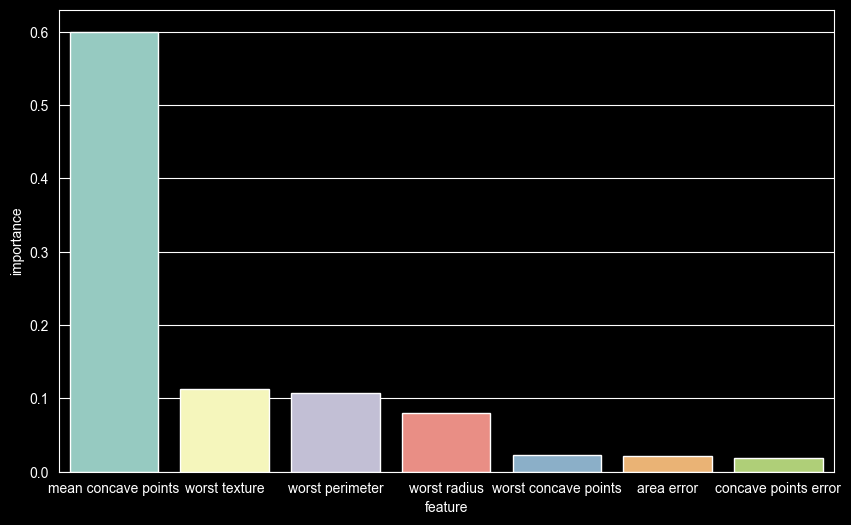

In [86]:
plt.figure(figsize=(10, 6))
sns.barplot(data=importance.head(7), x='feature', y='importance', hue='feature')

<BarContainer object of 5 artists>

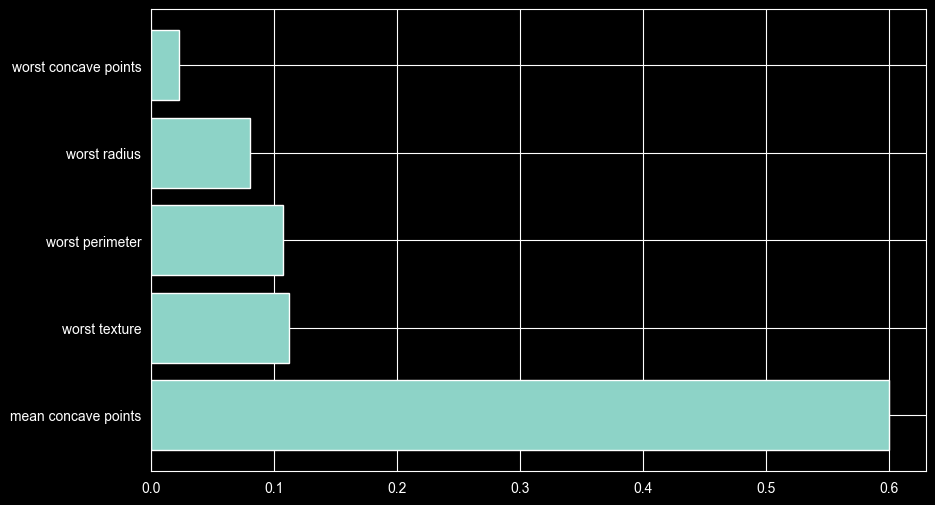

In [89]:
top5 = importance.head(5)

plt.figure(figsize=(10, 6))
plt.barh(top5['feature'], top5['importance'])

In [75]:
sns.heatmap(data=importance, x='feature', y='importance', cmap='viridis')

ValueError: could not convert string to float: 'mean concave points'

In [79]:
# fix
importance_matrix = importance.set_index('feature')
importance_matrix

,importance
feature,
mean concave points,0.600002
worst texture,0.112280
worst perimeter,0.107362
worst radius,0.080607
worst concave points,0.022416
area error,0.022019
concave points error,0.018943
worst area,0.014015
mean radius,0.013099


In [80]:
importance_matrix.T

feature,mean concave points,worst texture,worst perimeter,worst radius,worst concave points,area error,concave points error,worst area,mean radius,perimeter error,...,texture error,radius error,mean fractal dimension,mean symmetry,mean concavity,mean compactness,mean smoothness,mean area,mean perimeter,worst fractal dimension
importance,0.600002,0.11228,0.107362,0.080607,0.022416,0.022019,0.018943,0.014015,0.013099,0.009256,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


<Axes: ylabel='feature'>

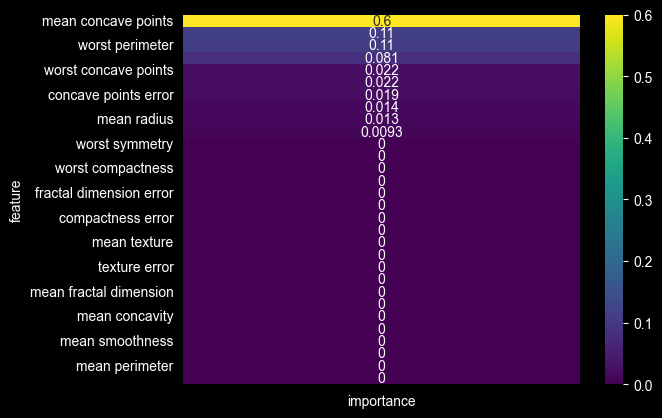

In [81]:
sns.heatmap(data = importance_matrix, annot=True, cmap='viridis')

[Text(0.5555555555555556, 0.9285714285714286, 'x[7] <= 0.051\nentropy = 0.952\nsamples = 455\nvalue = [169, 286]'),
 Text(0.2777777777777778, 0.7857142857142857, 'x[20] <= 16.83\nentropy = 0.314\nsamples = 282\nvalue = [16, 266]'),
 Text(0.4166666666666667, 0.8571428571428572, 'True  '),
 Text(0.16666666666666666, 0.6428571428571429, 'x[13] <= 48.7\nentropy = 0.136\nsamples = 263\nvalue = [5, 258]'),
 Text(0.1111111111111111, 0.5, 'x[21] <= 30.145\nentropy = 0.091\nsamples = 260\nvalue = [3, 257]'),
 Text(0.05555555555555555, 0.35714285714285715, 'entropy = 0.0\nsamples = 225\nvalue = [0, 225]'),
 Text(0.16666666666666666, 0.35714285714285715, 'x[23] <= 641.6\nentropy = 0.422\nsamples = 35\nvalue = [3, 32]'),
 Text(0.1111111111111111, 0.21428571428571427, 'entropy = 0.0\nsamples = 25\nvalue = [0, 25]'),
 Text(0.2222222222222222, 0.21428571428571427, 'x[0] <= 13.45\nentropy = 0.881\nsamples = 10\nvalue = [3, 7]'),
 Text(0.16666666666666666, 0.07142857142857142, 'entropy = 0.811\nsamples

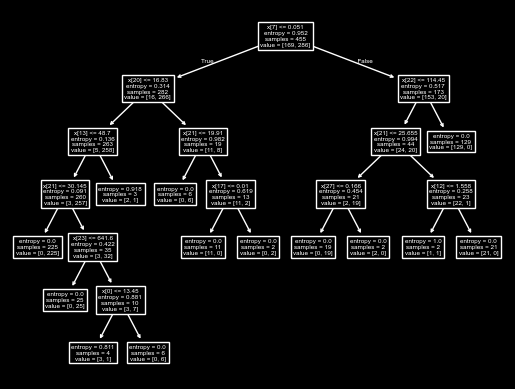

In [94]:
from sklearn.tree import plot_tree

plot_tree(best_model)